# 6-22-2026

Fitting to the measured passbands when we had a stationary half-wave plate.

The fitting steps are:

1. Look at pointings that share the same boresight and so stationary HWP position.
2. Group passbands based on detector polarization angle.
3. Average detector passbands for a given polarization angle
4. Apply beam splitter correction
5. Normalize according to max snr band
6. Fit to model

The model is:

$$
B(\nu) = \alpha(\theta_{det}) R(\nu) sin(\theta_{det} + \theta_{HWP, stationary} + \theta_{HWP}(\nu))
$$

where:

- $\theta_{det}$ is the detector's polarization angle
- $\alpha(\theta_{det})$ is like a gain calibration factor for the averaged passband for a given detector polarization angle
- $R(\nu)$ is the band response (typically modeled like an nth order polynomial, starting with 5th order)
- $\theta_{HWP}(\nu)$ is the HWP phase shift spectrum. There are two options: (1) as measured by the VNA and (2) as measured by the FTS.


In [1]:
# Basic imports
import numpy as np
import matplotlib.pyplot as plt
import os

# For loading contexts
from sotodlib import core

import pprint
import sys
import glob
import yaml
import time
import datetime as dt
import matplotlib as mpl
import scipy.signal as signal
import scipy.optimize as opt
from scipy import stats
from latrt_testing import utils
import latrt_testing.demodulation as demod
from random import randrange
import latrt_testing.fft_ops as fft_ops
from so3g.hk import load_range

from sotodlib.io.load_smurf import * 
from sotodlib.tod_ops.fft_ops import rfft
from sotodlib.tod_ops.detrend import detrend_tod
from sotodlib.tod_ops import pca
from sotodlib.io import load_smurf
from sotodlib.io import hkdb

import logging
logger.setLevel(logging.DEBUG)

import sotodlib
from sotodlib.tod_ops.flags import get_glitch_flags, get_trending_flags
import importlib
from scipy.optimize import curve_fit

from sotodlib.tod_ops import flags, detrend_tod, jumps, gapfill, pca, filters, apodize, fft_ops
from sotodlib.core.flagman import has_any_cuts, has_all_cut
from pixell import utils
from scipy.signal import welch
from scipy.signal import hilbert

from matplotlib.markers import MarkerStyle
import scipy
import pickle

Loaded new demodulation.py


/global/homes/s/shreyasu/lart_testing_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [139]:
import re
import pandas as pd
import math
from scipy.optimize import least_squares
import astropy.units as u
from scipy.optimize import basinhopping

# Load data

In [4]:
# load the bands
with open('/global/homes/s/shreyasu/SAT FTS Analysis 202602/FTS_data_mv19/bands_pW_obs1_90GHz_260527.pkl', 'rb') as f:
    mv19_obs1 = pickle.load(f)
    
with open('/global/homes/s/shreyasu/SAT FTS Analysis 202602/FTS_data_mv19/bands_pW_obs4_90GHz_260527.pkl', 'rb') as f:
    mv19_obs4 = pickle.load(f)

In [17]:
# load in hwp phase shift data - vna
mf1_ahwp = pd.read_csv('/global/homes/s/shreyasu/SAT FTS Analysis 202602/otherdata/MF1_AHWP_spectra.csv')

# fts hwp phase shift
with open('/global/homes/s/shreyasu/SAT FTS Analysis 202602/FTS_data_mv18/phases_avg_run1_260527.pkl', 'rb') as f:
    data_mv18_hwp = pickle.load(f)

In [11]:
mv19_obs1['passband_results']

[{'det_name': 'sch_ufm_mv19_1765462502_4_028',
  'det_band': 4.0,
  'det_channel': 28.0,
  'band_pW': array([2.92822427e-05, 3.34753202e-05, 7.72344257e-05, 5.90490720e-05,
         1.33975760e-04, 5.75215394e-04, 1.69076121e-04, 2.43872860e-04,
         4.76589564e-04, 7.41048863e-04, 4.25653973e-04, 2.23812254e-04,
         4.73345850e-04, 2.79515375e-04, 1.71535658e-04, 1.38054993e-04,
         8.33733578e-05, 2.05090459e-04, 5.45167466e-04, 4.54401091e-04,
         5.11846646e-04, 4.15761773e-04, 6.42676255e-04, 4.42364747e-04,
         7.25373917e-04, 2.38266219e-04, 4.86146750e-04, 4.10423317e-04,
         2.44948010e-04, 4.61916458e-04, 3.87825796e-04, 9.44813950e-05,
         3.16695716e-04, 5.52866643e-04, 1.90246957e-04, 3.56465889e-04,
         5.09829333e-04, 3.72805414e-04, 3.34144386e-04, 4.02365223e-04,
         3.66806972e-04, 4.23310863e-04, 1.74346313e-04, 5.15485398e-04,
         1.79318885e-04, 6.85155620e-04, 6.04032884e-04, 5.32008180e-04,
         4.25586897e-04,

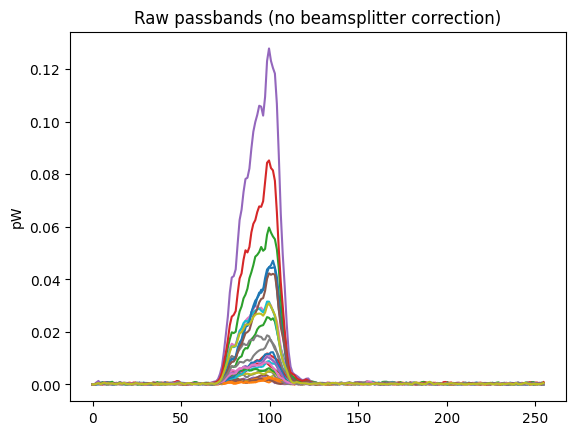

In [16]:
# Inspect bands (just for obs1 as an example)
plt.figure()

for i in range(len(mv19_obs1['passband_results'])):
    band_results = mv19_obs1['passband_results'][i]
    freq, band = band_results['frequency_ghz'], band_results['band_pW']
    plt.plot(freq, band)
plt.title('Raw passbands (no beamsplitter correction)')
plt.ylabel('pW')
plt.show()

# General band processing
1. Obs1 and obs4 measure different polarization angles
2. Sort detectors with respect to their polarization angle
3. store averaged bands per polarization angle grouping. If using the storing function average_grouped_bands for the 150GHz datasets, replaced key "band_pW" with "band".

In [ ]:
# Preprocesssing to get the obs 1 and obs 4 data
xi1  = np.array([result['xi']  for result in mv19_obs1['passband_results']])
eta1 = np.array([result['eta'] for result in mv19_obs1['passband_results']])

# detector polarization angle
gamma1 = np.array([result['gamma'] for result in mv19_obs1['passband_results']])

In [19]:
xi4  = np.array([result['xi']  for result in mv19_obs4['passband_results']])
eta4 = np.array([result['eta'] for result in mv19_obs4['passband_results']])
gamma4 = np.array([result['gamma'] for result in mv19_obs4['passband_results']])

In [34]:
# Store SNR of these obs' bands
snrs1 = np.array([result['snr_local'] for result in mv19_obs4['passband_results']])
snrs4 = np.array([result['snr_local'] for result in mv19_obs4['passband_results']])

In [35]:
print('snrs for obs1 bands:', snrs1)
print('snrs for obs4 bands:', snrs4)

snrs for obs1 bands: [  5.37363404  70.14052741 104.51224286  63.67207797   6.24410986
   7.31803605  32.36486077  29.35007433  21.32900116  24.67344061
  48.99691095   7.45634583 310.70666511 195.83615579   5.48159322
   8.44665375  43.68601191   5.10076047  23.30039342  20.96674293
   8.85885155 128.22196451]
snrs for obs4 bands: [  5.37363404  70.14052741 104.51224286  63.67207797   6.24410986
   7.31803605  32.36486077  29.35007433  21.32900116  24.67344061
  48.99691095   7.45634583 310.70666511 195.83615579   5.48159322
   8.44665375  43.68601191   5.10076047  23.30039342  20.96674293
   8.85885155 128.22196451]


In [20]:
# Define the 12 colors for the 12 polarization angle groups
colors = ['#a6cee3',
'#1f78b4',
'#b2df8a',
'#33a02c',
'#fb9a99',
'#e31a1c',
'#fdbf6f',
'#ff7f00',
'#cab2d6',
'#6a3d9a',
'goldenrod', #'#ffff99',
'#b15928']

In [ ]:
# # compare freqs for 1 and 4
# f1 = np.array(mv19_obs1['passband_results'][0]['frequency_ghz'])
# f4 = np.array(mv19_obs4['passband_results'][0]['frequency_ghz'])
# if np.array_equal(f1, f4):
#     print('True')

# the frequency arrays are the same so we can just set a shared freqency array
f = np.array(mv19_obs1['passband_results'][0]['frequency_ghz'])

True


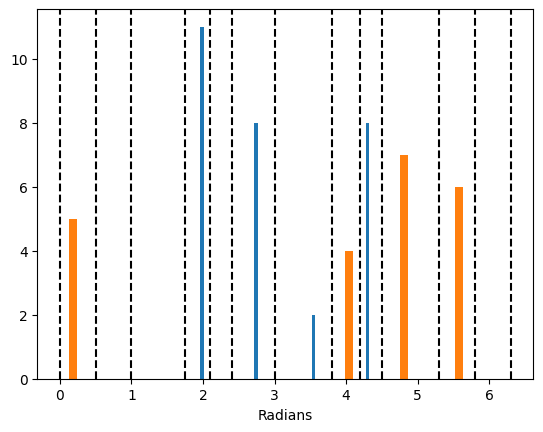

In [ ]:
# Plot polarizaiton angle

# Pol angle grouping bounds:
bounds = [0, 0.5, 1, 1.75, 2.1, 2.4, 3, 3.8, 4.2, 4.5, 5.3, 5.8, 6.3]

plt.figure()
plt.hist(gamma1, bins = 50)
plt.hist(gamma4, bins = 50)
for x in bounds:
    plt.axvline(x, color='k', ls='--')
plt.xlabel('Radians')
plt.show()

In [28]:
# Sort the detectors into their polarization angle groups
n_groups = len(bounds) - 1
print(n_groups)

# automatically sort detector indices into n_groups phase groups
groups_obs1 = [[] for _ in range(n_groups)]
for i, gamma in enumerate(gamma1):
    for j in range(n_groups):
        if bounds[j] <= gamma < bounds[j + 1]:
            groups_obs1[j].append(i)
            break

groups_obs4 = [[] for _ in range(n_groups)]
for i, gamma in enumerate(gamma4):
    for j in range(n_groups):
        if bounds[j] <= gamma < bounds[j + 1]:
            groups_obs4[j].append(i)
            break

12


In [29]:
print('groups1:', groups_obs1)
print('groups4:', groups_obs4)

groups1: [[], [], [], [1, 4, 5, 12, 14, 16, 17, 18, 23, 24, 27], [], [3, 6, 7, 9, 15, 22, 26, 28], [8, 21], [], [0, 2, 10, 11, 13, 19, 20, 25], [], [], []]
groups4: [[5, 8, 9, 15, 19], [], [], [], [], [], [], [11, 14, 16, 18], [], [1, 2, 4, 6, 10, 13, 21], [0, 3, 7, 12, 17, 20], []]


In [ ]:
# Get the averaged pol angle per group
gammas_avg = [[] for _ in range(n_groups)] # will be stored in degrees

for i, (group_obs4, group_obs1, color) in enumerate(zip(groups_obs4, groups_obs1, colors)):
    if len(group_obs4) > 0:
        gamma_avg = np.degrees(np.mean(gamma4[group_obs4]))
        gammas_avg[i] = gamma_avg
    else:
        gamma_avg = np.degrees(np.mean(gamma1[group_obs1]))
        gammas_avg[i] = gamma_avg
    if math.isnan(gamma_avg):
        continue

/global/homes/s/shreyasu/lart_testing_env/lib/python3.10/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/global/homes/s/shreyasu/lart_testing_env/lib/python3.10/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)


In [31]:
print(gammas_avg)

[7.6715493, nan, nan, 112.514824, nan, 157.63658, 202.64531, 232.53738, 247.5218, 277.48196, 322.6143, nan]


In [36]:
# Function to store the averaged passbands per pol angle grouping
def average_grouped_bands(groups, passband_results, snr_threshold=5,
                          correction=None, norm_fac=1.0):
    """
    Average bands within each group, with optional correction and normalization.
    
    Parameters
    ----------
    groups : list of lists
        Group indices into passband_results.
    passband_results : list of dicts
        Each dict has 'band', 'frequency_ghz', 'snr_local'.
    snr_threshold : float
        Minimum SNR to include a band.
    correction : array-like or None
        Divide averaged band by this (e.g. R_25um_pp). None = no correction.
    norm_fac : float
        Multiply after correction. Default 1.0 (no normalization).
    
    Returns
    -------
    list : averaged (and optionally corrected/normalized) band per group.
    """
    n_groups = len(groups)
    bands = [None] * n_groups

    for g_idx, group in enumerate(groups):
        band_sum = 0
        band_counter = 0

        for j in (group if group else []):
            result = passband_results[j]
            snr = result['snr_local']
            if snr >= snr_threshold:
                band_sum = np.array(result['band_pW']) + band_sum
                band_counter += 1

        if band_counter:
            band_avg = band_sum / band_counter
            if correction is not None:
                band_avg = band_avg / correction
            bands[g_idx] = band_avg * norm_fac
        else:
            bands[g_idx] = float('nan')

    return bands

In [37]:
SNR_THRESHOLD = 5

# Raw averages - no beamsplitter correction
bands_groups1 = average_grouped_bands(
    groups_obs1, mv19_obs1['passband_results'], snr_threshold=SNR_THRESHOLD
)

bands_groups4 = average_grouped_bands(
    groups_obs4, mv19_obs4['passband_results'], snr_threshold=SNR_THRESHOLD
)

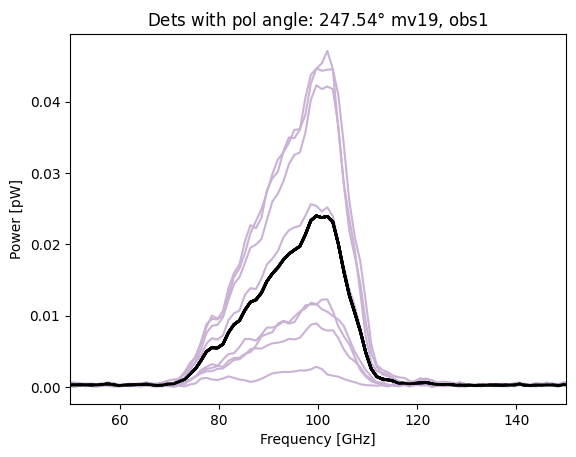

In [ ]:
# Plot the bands per group since we're going to average these 

plt.figure()

# group index;
g_idx = 8
for j in groups_obs1[g_idx]:
    band_avg = bands_groups1[g_idx]
    result = data_mv19_obs1['passband_results'][j]
    band = result['band_pW']
    freq = result['frequency_ghz']
    snr = result['snr_local']
    gamma = float(np.degrees(result['gamma']))
    if snr >= 5:
        plt.plot(freq, band, label=f'snr = {np.round(snr)}', color=colors[g_idx], alpha=1)
    plt.plot(freq, band_avg, color='k', lw=2)

plt.xlim(50, 150)
plt.title(rf'Dets with pol angle: {np.round(gamma, 2)}$\degree$ mv19, obs1')
plt.xlabel('Frequency [GHz]')
plt.ylabel('Power [pW]')
# plt.legend()
plt.show()

# Apply beamsplitter correction

In [40]:
# correction function
def reflectance_s_polarized_complex(n0, n1, d, theta_i, wavelength):
    # n1 may be complex
    theta_t1 = np.arcsin((n0 / np.real(n1)) * np.sin(theta_i))  # Approximation: use real part for angle
    # For accurate modeling, use complex n1 in cos(theta_t1):
    cos_theta_t1 = np.sqrt(1 - (n0*np.sin(theta_i)/n1)**2)

    # Fresnel coefficients for s-polarized (with complex n1)
    rs01 = (n0 * np.cos(theta_i) - n1 * cos_theta_t1) / (n0 * np.cos(theta_i) + n1 * cos_theta_t1)
    ts01 = (2 * n0 * np.cos(theta_i)) / (n0 * np.cos(theta_i) + n1 * cos_theta_t1)

    rs12 = (n1 * cos_theta_t1 - n0 * np.cos(theta_i)) / (n1 * cos_theta_t1 + n0 * np.cos(theta_i))

    # Complex phase thickness
    delta = (2 * np.pi * n1 * d * cos_theta_t1) / wavelength   # delta is complex
    
    # Interference with absorption
    numerator = rs01**2 + rs12**2 + 2 * rs01 * rs12 * np.cos(2 * np.real(delta)) * np.exp(-2 * np.imag(delta))
    denominator = 1 + (rs01 * rs12)**2 + 2 * rs01 * rs12 * np.cos(2 * np.real(delta)) * np.exp(-2 * np.imag(delta))
    Rs = np.abs(numerator/denominator)
    return Rs

In [42]:
# beamsplitter correction

# constants
c = 2.9979e8 
theta_i = 34.889 # degrees, aoi
n, eps = 1.5,2.25
k= 1j*np.emath.sqrt(n**2 -eps)
N = n + 1j*k
print(N)
print(k)

# f: shared freuqency array in GHz
f_ghz = f * u.GHz
f_hz = f_ghz.to(u.Hz)
f_wavelengths = c / f_hz

R_25um_pp = reflectance_s_polarized_complex(1, N, 25.4e-6, theta_i, f_wavelengths.value) # 25.4 um thickness# complex index for PP

# store bands with beamsplitter correction
bands_groups1_bs = average_grouped_bands(
    groups_obs1, mv19_obs1['passband_results'], snr_threshold=SNR_THRESHOLD,
    correction=R_25um_pp
)
bands_groups4_bs = average_grouped_bands(
    groups_obs4, mv19_obs4['passband_results'], snr_threshold=SNR_THRESHOLD,
    correction=R_25um_pp
)

(1.5+0j)
0j


/global/homes/s/shreyasu/lart_testing_env/lib/python3.10/site-packages/astropy/units/quantity.py:671: RuntimeWarning: divide by zero encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/tmp/ipykernel_365394/3885541513.py:41: RuntimeWarning: divide by zero encountered in divide
  band_avg = band_avg / correction


In [55]:
# store bands with beamsplitter correction and normalized to below 1

# set lower index to mask the lower freq data
lower_ind = 50

norm_fac = 1.0 / np.nanmax(bands_groups4_bs[9][lower_ind:])

bands_groups1_bs_norm = average_grouped_bands(
    groups_obs1, mv19_obs1['passband_results'], snr_threshold=SNR_THRESHOLD,
    correction=R_25um_pp, norm_fac=norm_fac
)
bands_groups4_bs_norm = average_grouped_bands(
    groups_obs4, mv19_obs4['passband_results'], snr_threshold=SNR_THRESHOLD,
    correction=R_25um_pp, norm_fac=norm_fac
)

/tmp/ipykernel_365394/3885541513.py:41: RuntimeWarning: divide by zero encountered in divide
  band_avg = band_avg / correction


# Plot beamsplitter corrected bands

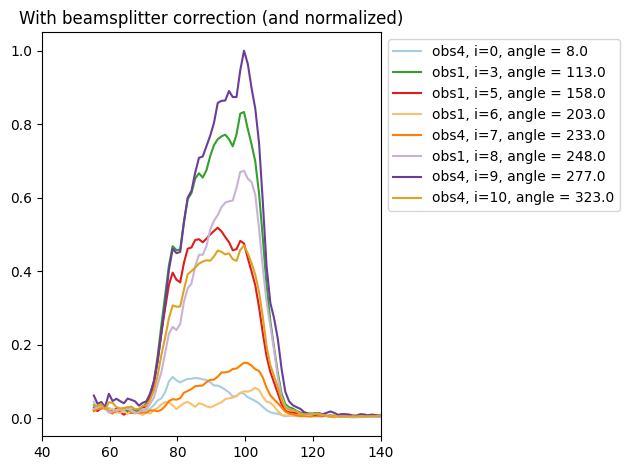

In [74]:
# plot each type of averaged band
plt.figure()


for i in range(n_groups):
    band1 = np.array(bands_groups1_bs_norm[i])
    band4 = np.array(bands_groups4_bs_norm[i])

    if np.ndim(band1) > 0:
        obs=1
        mask1 = ~np.isnan(band1)
        plt.plot(f[mask1][lower_ind:], band1[mask1][lower_ind:], color=colors[i], label=f'obs{obs}, i={i}, angle = {np.round(gammas_avg[i])}')

    if np.ndim(band4) > 0:
        obs=4
        mask4 = ~np.isnan(band4)
        plt.plot(f[mask4][lower_ind:], band4[mask4][lower_ind:], color=colors[i], label=f'obs{obs}, i={i}, angle = {np.round(gammas_avg[i])}')

# for i in range(n_groups):
#     band1 = np.array(bands_groups1[i])
#     band4 = np.array(bands_groups4[i])

#     if np.ndim(band1) > 0:
#         mask1 = ~np.isnan(band1)
#         plt.plot(f[mask1], np.array(band1[mask1]) / np.nanmax(bands_groups4[9]), color='grey', alpha=0.5)

#     if np.ndim(band4) > 0:
#         mask4 = ~np.isnan(band4)
#         plt.plot(f[mask4], np.array(band4[mask4]) / np.nanmax(bands_groups4[9]), color='grey', alpha=0.5)
plt.legend(bbox_to_anchor=(1,1))
plt.title('With beamsplitter correction (and normalized)')

plt.xlim(40, 140)

# plt.ylim(0, 30)
plt.tight_layout()
plt.show()

# Phase angle fitting
Now we fit simple polynomials to the HWP phase angle spectra so we can later use these in the model.

In [69]:
bands_groups1_bs_norm[1]

nan

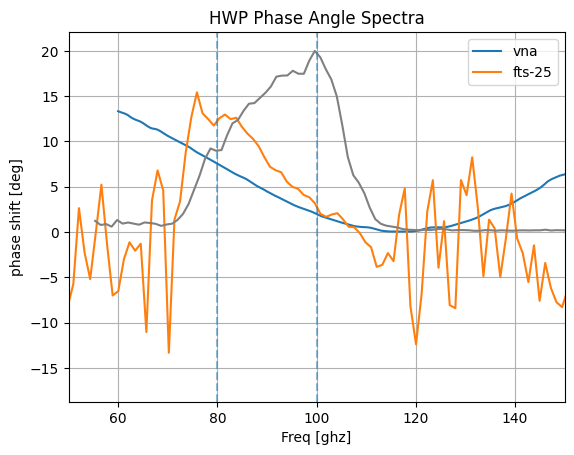

In [93]:
plt.figure()
plt.plot(mf1_ahwp['frequency (GHz)'], mf1_ahwp['phase shift (deg)'], label='vna')

# subtract constant from the fts phase angle measurement bc this offset is relative
offset_constant = 25
plt.plot(data_mv18_hwp['freq'], data_mv18_hwp['avg_phases90'] - offset_constant, label=f'fts-{offset_constant}')

# plot band over the region
plt.plot(f[lower_ind:], bands_groups4_bs_norm[9][lower_ind:] * 20, color='grey')

# only fit to the in-band region for the fts spectrum
hwp_bounds = [80, 100]
plt.axvline(hwp_bounds[0], alpha=0.5, ls='--')
plt.axvline(hwp_bounds[1], alpha=0.5, ls='--')

plt.xlim(50, 150)
plt.legend()
plt.title('HWP Phase Angle Spectra')
plt.xlabel('Freq [ghz]')
plt.ylabel('phase shift [deg]')
plt.grid('True')
plt.show()

In [104]:
# mask the hwp phase angle spectra and fit quadratics

f_hwp_vna = np.array(mf1_ahwp['frequency (GHz)'])
ps_hwp_vna = np.array(mf1_ahwp['phase shift (deg)'])
mask_vna = np.where((f_hwp_vna >= hwp_bounds[0])&(f_hwp_vna <= hwp_bounds[1]))

f_hwp_fts = np.array(data_mv18_hwp['freq'])
ps_hwp_fts = np.array(data_mv18_hwp['avg_phases90']) - offset_constant
mask_fts = np.where((f_hwp_fts >= hwp_bounds[0])&(f_hwp_fts <= hwp_bounds[1]))

In [105]:
# fit quadratic
quad_coeffs_vna = np.polyfit(f_hwp_vna[mask_vna], ps_hwp_vna[mask_vna], 2)
quad_coeffs_fts = np.polyfit(f_hwp_fts[mask_fts], ps_hwp_fts[mask_fts], 2)

In [106]:
# resulting fitted function
func0_vna = np.poly1d(quad_coeffs_vna)
func0_fts = np.poly1d(quad_coeffs_fts)

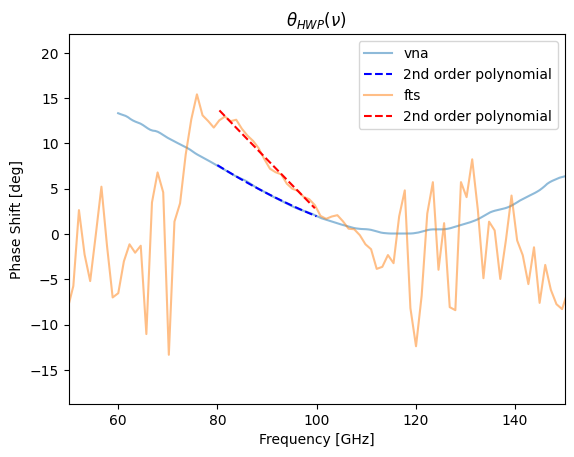

In [113]:
plt.figure()

## VNA
plt.plot(f_hwp_vna, ps_hwp_vna, label='vna', alpha=0.5)
plt.plot(f_hwp_vna[mask_vna], func0_vna(f_hwp_vna[mask_vna]), color='b', ls='--', label='2nd order polynomial')

# ## FTS
plt.plot(f_hwp_fts, ps_hwp_fts, label='fts', alpha=0.5)
plt.plot(f_hwp_fts[mask_fts], func0_fts(f_hwp_fts[mask_fts]), color='r', ls='--', label='2nd order polynomial')

plt.legend()
plt.xlabel('Frequency [GHz]')
plt.ylabel('Phase Shift [deg]')
plt.title(r'$\theta_{HWP}(\nu)$')
plt.xlim(50, 150)
plt.show()

# Band Response Fit
Fitting a fifth-order $R(\nu)$ polynomial to the highest SNR band to have a guess. it may make more sense to get these parameters for the flattest band actually

In [196]:
# fifht order fit
freq_fitting_bounds = [80, 100]
mask = (f >= freq_fitting_bounds[0]) & (f <= freq_fitting_bounds[1])

band_idx = 5# = 9 with bands_groups4 for the highest Snr band
order = 5 # start with fifth order polynomial
coeffs_band = np.polyfit(f[mask], bands_groups1_bs_norm[band_idx][mask], order)
p_band_func = np.poly1d(coeffs_band)
# p_band_fit = p_band_func(f[mask])

# # if deciding to look at the flattest band instead
# band_idx = 5
# coeffs_band = np.polyfit(f[mask], bands_groups1_bs_norm[band_idx][mask], order)
# p_band_func = np.poly1d(coeffs_band)

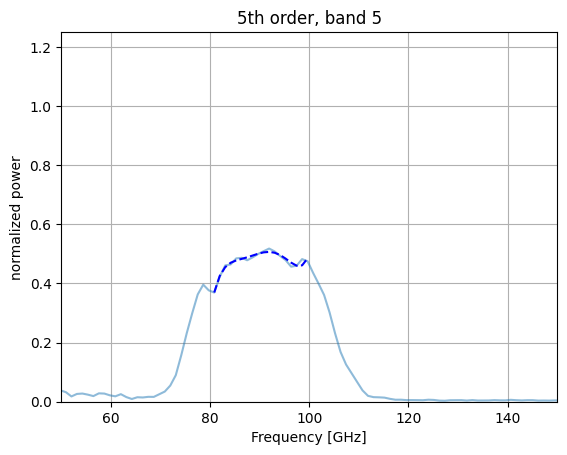

In [197]:
plt.figure()
plt.plot(f, bands_groups1_bs_norm[band_idx], alpha=0.5)
# plt.plot(f, bands_groups1[band_idx] * 28, alpha=0.5)

# if the flatter band is used:
# plt.plot(f, bands_groups1_bs_norm[5], alpha=0.5)

# plt.plot(f[mask], bands_groups4_bs_norm[band_idx][mask])
plt.plot(f[mask], p_band_func(f[mask]), color='b', ls='--')
plt.xlim(50, 150)
plt.ylim(0, 1.25)
plt.title(f'{order}th order, band {band_idx}')
plt.xlabel('Frequency [GHz]')
plt.ylabel('normalized power')
plt.grid('True')
plt.show()

# FIT 1 - fit to all

$$
B(\nu) = \alpha(\theta_{det}) R(\nu) sin(\theta_{det} + \theta_{HWP, stationary} + \theta_{HWP}(\nu))
$$

Fix:
- $\theta_{det}$
- $\theta_{HWP}(\nu)$ - choose vna or fts

Fit to:
- $\alpha(\theta_{det})$
- $R(\nu)$ (5th order to start with)
- $\theta_{HWP, stationary}$

In [198]:
# ── config ──────────────────────────────────────────────────────────────────
POLY_DEG = order     # R(nu)
BAND_INDICES = [0, 3, 5, 6, 7, 8, 9, 10]
n_bands = len(BAND_INDICES)

# which index comes from which obs
BAND_SOURCES = {
    0: bands_groups4_bs_norm, 3: bands_groups1_bs_norm, 5: bands_groups1_bs_norm, 6: bands_groups1_bs_norm,
    7: bands_groups4_bs_norm, 8: bands_groups1_bs_norm, 9: bands_groups4_bs_norm, 10: bands_groups4_bs_norm,
}

In [199]:
# ── model functions ──────────────────────────────────────────────────────────
def R_nu(x, poly_coeffs):
    """Polynomial band response; degree = len(poly_coeffs) - 1."""
    return np.polyval(poly_coeffs, x)

# two versions of the model:

# using vna hwp
def func3_vna(x, angle_pol, angle, const, alpha, poly_coeffs):
    # # Phase shift with vna
    angles_phase_shift = np.radians(func0_vna(x))

    angle_pol = np.radians(angle_pol)
    angle_rad = np.radians(angle)
    sine_arg = angle_pol + angles_phase_shift + angle
    R = R_nu(x, poly_coeffs)
    return alpha * R * np.sin(sine_arg) + const

# using fts hwp
def func3_fts(x, angle_pol, angle, const, alpha, poly_coeffs):
    # phase shift with fts
    angles_phase_shift = np.radians(func0_fts(x))

    angle_pol = np.radians(angle_pol)
    angle_rad = np.radians(angle)
    sine_arg = angle_pol + angles_phase_shift + angle
    R = R_nu(x, poly_coeffs)
    return alpha * R * np.sin(sine_arg) + const

In [231]:
# ── error function ───────────────────────────────────────────────────────────
# two versions of the error function (vna and fts)
def error_func3_vna(params, x_data_list, y_data_list, gammas):
    """
    params layout: [alpha_0, ..., alpha_n, angle_stat, poly_coeff_0, ..., poly_coeff_d]
    """
    n_bands = len(BAND_INDICES)
    alphas = params[:n_bands]
    angle_stat = params[n_bands]
    poly_coeffs = params[n_bands + 1:]          # length = POLY_DEG + 1

    freqs = x_data_list[0]
    residuals = [
        y_data_list[i] - np.abs(func3_vna(freqs, gammas[i], angle_stat, Cguess, alphas[i], poly_coeffs))
        for i in range(n_bands)
    ]
    return np.concatenate(residuals)

def error_func3_fts(params, x_data_list, y_data_list, gammas):
    """
    params layout: [alpha_0, ..., alpha_n, angle_stat, poly_coeff_0, ..., poly_coeff_d]
    """
    n_bands = len(BAND_INDICES)
    alphas = params[:n_bands]
    angle_stat = params[n_bands]
    poly_coeffs = params[n_bands + 1:]          # length = POLY_DEG + 1

    freqs = x_data_list[0]
    residuals = [
        y_data_list[i] - np.abs(func3_fts(freqs, gammas[i], angle_stat, Cguess, alphas[i], poly_coeffs))
        for i in range(n_bands)
    ]
    return np.concatenate(residuals)

In [232]:
# ── prepare data ─────────────────────────────────────────────────────────────
freq_fitting_bounds = [80, 100]
mask = (f >= freq_fitting_bounds[0]) & (f <= freq_fitting_bounds[1])

x_data_list = [f[mask]] * len(BAND_INDICES)

y_data_list = [BAND_SOURCES[i][i][mask] for i in BAND_INDICES]

# we have data for 8 out of 12 detector polarization angles, so limit gammas to just
# the polarization angles we have data for
gammas = [gammas_avg[i] for i in BAND_INDICES]

In [233]:
# prepare initial guesses

# for alpha(\theta_{det}) use the in-band mean
def masked_mean(band, mask):
    band = np.asarray(band)
    if band.ndim == 0:   # empty-group placeholder (scalar nan)
        return np.nan
    return np.nanmean(band[mask])

# calculate means of in-bands (len = 12 here)
alpha_guesses_inband = [
    np.nanmean([masked_mean(bands_groups1_bs_norm[i], mask),
                masked_mean(bands_groups4_bs_norm[i], mask)])
    for i in range(n_groups)
]

# keep just the 8 values that correspond to bands
alpha_p0 = [alpha_guesses_inband[i] + 0.1 for i in BAND_INDICES] 

# stationary angle guess
angle_p0 = [230] # deg

# R(nu) polynomial coeff guess
poly_p0  = list(coeffs_band[:POLY_DEG + 1])   # must supply POLY_DEG+1 coeffs

# combine all initial paraemters
p0_v3 = alpha_p0 + angle_p0 + poly_p0

# constant - just set to zero for now - this is not a fitting value
Cguess = 0


/tmp/ipykernel_365394/1933362183.py:12: RuntimeWarning: Mean of empty slice
  np.nanmean([masked_mean(bands_groups1_bs_norm[i], mask),


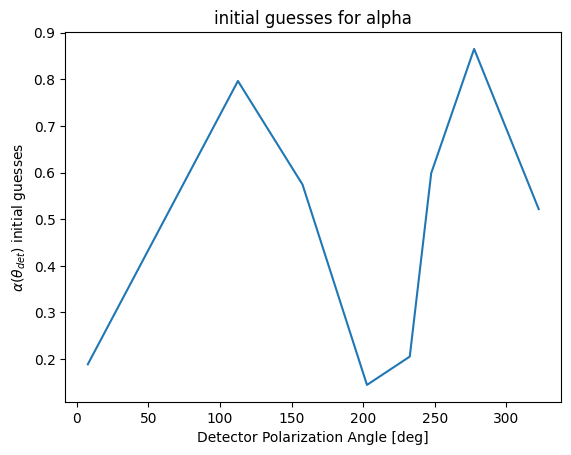

In [234]:
# check iniital params
plt.figure()
plt.plot(gammas, alpha_p0)
plt.xlabel('Detector Polarization Angle [deg]')
plt.ylabel(r'$\alpha(\theta_{det})$ initial guesses')
plt.title('initial guesses for alpha')
plt.show()

In [236]:
# restrict alphas to be between [0.1, 10]

# lower bounds
lb = [-np.inf] * len(p0_v3) #[-np.inf] * len(p0_v3)
lb[:n_bands] = [0.1] * n_bands # first n_bands values are for the alphas

ub = [ np.inf] * len(p0_v3)
ub[:n_bands] = [10] * n_bands

print('lower fitting bonds:', lb)
print('upper fitting bounds:', ub)

lower fitting bonds: [0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, -inf, -inf, -inf, -inf, -inf, -inf, -inf]
upper fitting bounds: [10, 10, 10, 10, 10, 10, 10, 10, inf, inf, inf, inf, inf, inf, inf]


In [237]:
# fitting using basin hopping to explore parameters in wider range
def scalar_error_v3_vna(params, x_data_list, y_data_list, gammas):
    residuals = error_func3_vna(params, x_data_list, y_data_list, gammas)
    return np.sum(residuals**2)

def scalar_error_v3_fts(params, x_data_list, y_data_list, gammas):
    residuals = error_func3_fts(params, x_data_list, y_data_list, gammas)
    return np.sum(residuals**2)

In [238]:
# fit
result1_vna = basinhopping(
    scalar_error_v3_vna,
    p0_v3,
    minimizer_kwargs={
        "method": "L-BFGS-B",
        "args": (x_data_list, y_data_list, gammas),
        "bounds": list(zip(lb, ub))  # L-BFGS-B expects [(lb0,ub0), (lb1,ub1), ...]
    })

In [239]:
result1_fts = basinhopping(
    scalar_error_v3_fts,
    p0_v3,
    minimizer_kwargs={
        "method": "L-BFGS-B",
        "args": (x_data_list, y_data_list, gammas),
        "bounds": list(zip(lb, ub))  # L-BFGS-B expects [(lb0,ub0), (lb1,ub1), ...]
    })

In [240]:
# unpack results

# vna
fitted_alphas1_vna  = dict(zip(BAND_INDICES, result1_vna.x[:n_bands]))
fitted_alphas_arr1_vna = result1_vna.x[:n_bands]
angle_stat_fit1_vna = result1_vna.x[n_bands]
Rpoly_fit1_vna       = result1_vna.x[n_bands + 1:]

In [241]:
# unpack results

# vna
fitted_alphas1_fts  = dict(zip(BAND_INDICES, result1_fts.x[:n_bands]))
fitted_alphas_arr1_fts = result1_fts.x[:n_bands]
angle_stat_fit1_fts = result1_fts.x[n_bands]
Rpoly_fit1_fts       = result1_fts.x[n_bands + 1:]

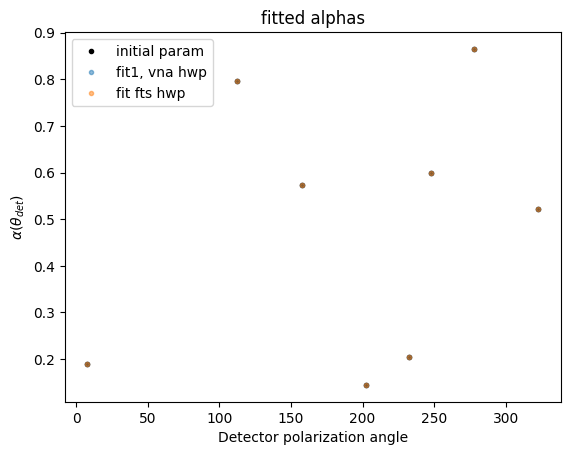

In [249]:
# Plot some of the results
plt.figure()
plt.plot(gammas, alpha_p0, '.', color='k', label='initial param')
plt.plot(gammas, fitted_alphas_arr1_vna, '.', alpha=0.5, label='fit1, vna hwp')
plt.plot(gammas, fitted_alphas_arr1_fts, '.', alpha=0.5, label='fit fts hwp')

# plt.axhline(0.1)
# plt.semilogy()
plt.legend()
plt.ylabel(r'$\alpha (\theta_{det})$')
plt.xlabel('Detector polarization angle')
plt.title('fitted alphas')
plt.show()

alphas don't seem to change at all after fitting

In [243]:
# compare fts vs vna hwp fit results
print('vna fits\n')
print('fitted alphas_vna:', fitted_alphas1_vna)
print('Rpoly_fit_vna:', Rpoly_fit1_vna)
print('angle stat fit_vna:', angle_stat_fit1_vna)

print('\nfts fits')
print('fitted alphas_vna:', fitted_alphas1_fts)
print('Rpoly_fit_vna:', Rpoly_fit1_fts)
print('angle stat fit_vna:', angle_stat_fit1_fts)

vna fits

fitted alphas_vna: {0: 0.1887143020914002, 3: 0.7964841579747725, 5: 0.5742521878516597, 6: 0.14443401473096518, 7: 0.20522698147829269, 8: 0.5987109458545472, 9: 0.8652652028273691, 10: 0.5215645661440445}
Rpoly_fit_vna: [ 2.62982182e-06 -1.18623544e-03  2.13796388e-01 -1.92481288e+01
  8.65675314e+02 -1.55595440e+04]
angle stat fit_vna: 230.0

fts fits
fitted alphas_vna: {0: 0.1887143020914002, 3: 0.7964841579747725, 5: 0.5742521878516597, 6: 0.14443401473096518, 7: 0.20522698147829269, 8: 0.5987109458545472, 9: 0.8652652028273691, 10: 0.5215645661440445}
Rpoly_fit_vna: [ 2.62982165e-06 -1.18623544e-03  2.13796388e-01 -1.92481288e+01
  8.65675314e+02 -1.55595440e+04]
angle stat fit_vna: 230.0


In [214]:
# R fits using fts vs vna hwp spectrum
Rfitfuncvna = np.poly1d(Rpoly_fit1_vna)
Rfitfuncfts = np.poly1d(Rpoly_fit1_fts)

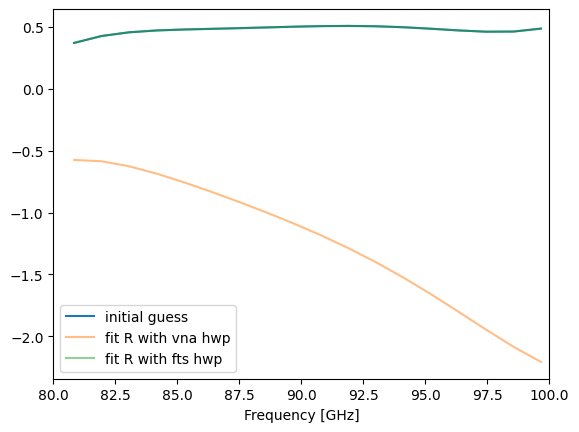

In [252]:
# compare polynomials for R
plt.figure()
# plt.plot(f[mask], guessfunc(f[mask]), label='guess from band 9')
# plt.plot(f[mask], fitfunc(f[mask]), label='fit only R')
plt.plot(f[mask], p_band_func(f[mask]), label='initial guess')
plt.plot(f[mask], Rfitfuncvna(f[mask]), label='fit R with vna hwp', alpha=0.5)
plt.plot(f[mask], Rfitfuncfts(f[mask]), label='fit R with fts hwp', alpha=0.5)

plt.legend()
plt.xlim(80, 100)
# plt.ylim(0, 3)
plt.xlabel('Frequency [GHz]')
plt.show()

# PLOT 1
Plot results from fit above

/global/homes/s/shreyasu/lart_testing_env/lib/python3.10/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/global/homes/s/shreyasu/lart_testing_env/lib/python3.10/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)


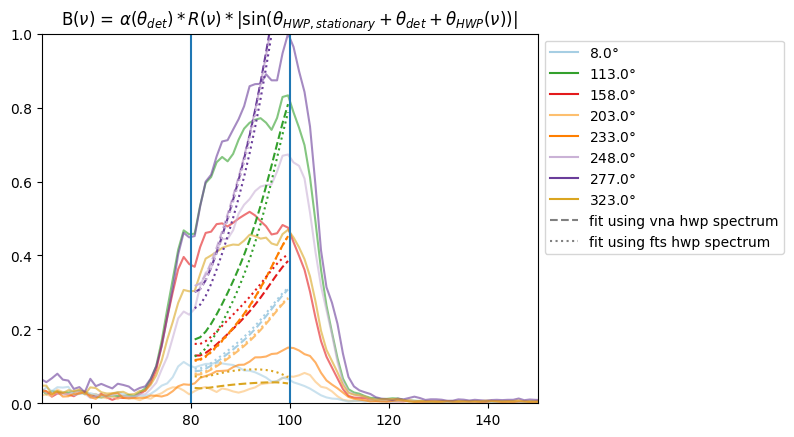

In [253]:
# ── plot ──────────────────────────────────────────────────────────────────────
plt.figure()
# fig, ax = plt.subplots(1, 2)

for i in range(n_groups):
    band = np.array(bands_groups1_bs_norm[i])
    freq = mv19_obs1['passband_results'][0]['frequency_ghz']
    mask_ = ~np.isnan(band)
    if mask_.any():
        plt.plot(freq[mask_], band[mask_], color=colors[i], alpha=0.6)

for i in range(n_groups):
    band = np.array(bands_groups4_bs_norm[i])
    freq = mv19_obs4['passband_results'][0]['frequency_ghz']
    mask_ = ~np.isnan(band)
    if mask_.any():
        plt.plot(freq[mask_], band[mask_], color=colors[i], alpha=0.6)
    
# fit1 when using vna hwp spectrum
for i, alpha_fit in fitted_alphas1_vna.items():
    y_fit = func3_vna(f[mask], gammas_avg[i], angle_stat_fit1_vna, Cguess, alpha_fit, Rpoly_fit1_vna)
    plt.plot(f[mask], np.abs(y_fit), color=colors[i], ls='--')

# fit 1 when using fts hwp spectrum
for i, alpha_fit in fitted_alphas1_fts.items():
    y_fit = func3_fts(f[mask], gammas_avg[i], angle_stat_fit1_fts, Cguess, alpha_fit, Rpoly_fit1_fts)
    plt.plot(f[mask], np.abs(y_fit), color=colors[i], ls=':')

# Label the pol angles
for i, (group_obs4, group_obs1, color) in enumerate(zip(groups_obs4, groups_obs1, colors)):
    if len(group_obs4) > 0:
        gamma_avg = np.degrees(np.mean(gamma4[group_obs4]))
        gammas_avg[i] = gamma_avg
    else:
        gamma_avg = np.degrees(np.mean(gamma1[group_obs1]))
        gammas_avg[i] = gamma_avg
    if math.isnan(gamma_avg):
        continue
    plt.plot([], [], color=color, label=rf'{np.round(gamma_avg)}$\degree$')

plt.plot([],[],color='grey', ls='--', label='fit using vna hwp spectrum')
plt.plot([],[],color='grey', ls=':', label='fit using fts hwp spectrum')

plt.legend(bbox_to_anchor=(1,1))
plt.xlim(50, 150)
plt.ylim(0, 1)

# plt.axvspan(130, 160, alpha=0.5)
plt.axvline(hwp_bounds[0])
plt.axvline(hwp_bounds[1])
# ax[0].axhline(0.06, ls='--')
# ax[1].axhline(0.06, ls='--')
equationString = r'B($\nu$) = $\alpha (\theta_{det}) * R(\nu) * |$sin($\theta_{HWP, stationary} + \theta_{det} + \theta_{HWP}(\nu)$)|'

plt.title(equationString)
plt.show()

In [255]:
# Residuals
residuals1_vna = {}

for i, alpha_fit in fitted_alphas1_vna.items():
    y_fit = func3_vna(f[mask], gammas_avg[i], angle_stat_fit1_vna, Cguess, alpha_fit, Rpoly_fit1_vna)
    # y_fit = np.abs(func3_vna(f[mask], gammas_avg[i], angle_stat_fit_posalpha, Cguess, alpha_fit, poly_fit_posalpha))
    y_fit_interp = np.interp(freq, f[mask], y_fit)

    residuals1_vna[i] = {}
    for obs, band_norm in [('obs1', bands_groups1_bs_norm[i]), ('obs4', bands_groups4_bs_norm[i])]:
        band = np.array(band_norm)
        if np.ndim(band) == 0:
            residuals1_vna[i][obs] = None
            continue
        mask_ = ~np.isnan(band)
        residuals1_vna[i][obs] = {
            'freq': freq[mask_],
            'resid': band[mask_] - y_fit_interp[mask_],
        }

In [256]:
# Residuals
residuals1_fts = {}

for i, alpha_fit in fitted_alphas1_fts.items():
    y_fit = func3_fts(f[mask], gammas_avg[i], angle_stat_fit1_fts, Cguess, alpha_fit, Rpoly_fit1_fts)
    # y_fit = np.abs(func3_fts(f[mask], gammas_avg[i], angle_stat_fit_posalpha, Cguess, alpha_fit, poly_fit_posalpha))
    y_fit_interp = np.interp(freq, f[mask], y_fit)

    residuals1_fts[i] = {}
    for obs, band_norm in [('obs1', bands_groups1_bs_norm[i]), ('obs4', bands_groups4_bs_norm[i])]:
        band = np.array(band_norm)
        if np.ndim(band) == 0:
            residuals1_fts[i][obs] = None
            continue
        mask_ = ~np.isnan(band)
        residuals1_fts[i][obs] = {
            'freq': freq[mask_],
            'resid': band[mask_] - y_fit_interp[mask_],
        }

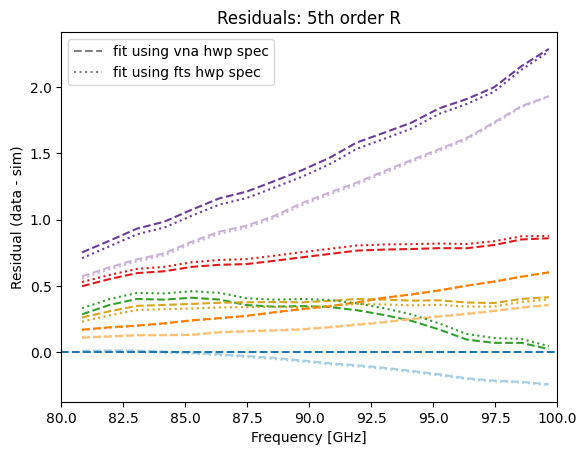

In [257]:
plt.figure()

# vna hwp residuals
for i, obs_residuals in residuals1_vna.items():
    for obs, val in obs_residuals.items():
        if val is not None:
            freq_mask = (val['freq'] >= hwp_bounds[0]) & (val['freq'] <= hwp_bounds[1])
            plt.plot(val['freq'][freq_mask], val['resid'][freq_mask], color=colors[i], ls='--')

# residuals when using the fts hwp spectrum
for i, obs_residuals in residuals1_fts.items():
    for obs, val in obs_residuals.items():
        if val is not None:
            freq_mask = (val['freq'] >= hwp_bounds[0]) & (val['freq'] <= hwp_bounds[1])
            plt.plot(val['freq'][freq_mask], val['resid'][freq_mask], color=colors[i], ls=':')

# dashed is with vna hwp spectrum
plt.plot([],[], color='grey', ls='--', label='fit using vna hwp spec')
plt.plot([],[], color='grey', ls=':', label='fit using fts hwp spec')

# plt.axvline(130, color='gray', lw=0.8)
plt.xlim(80, 100)
plt.axhline(0, ls='--')
plt.legend()
plt.xlabel('Frequency [GHz]')
plt.ylabel('Residual (data - sim)')
plt.title(f'Residuals: {order}th order R')
plt.show()

# FIT 2 - fit to just R(nu)
$$
B(\nu) = \alpha(\theta_{det}) R(\nu) sin(\theta_{det} + \theta_{HWP, stationary} + \theta_{HWP}(\nu))
$$

Fix:
- $\theta_{det}$
- $\theta_{HWP}(\nu)$ - choose vna or fts
- $\theta_{HWP, stationary}$ - use previous fit value as initial param
- $\alpha(\theta_{det})$ - use prevoius fit value as the initial param

Fit to:
- $R(\nu)$ (5th order to start with)


In [258]:
# ── error function ───────────────────────────────────────────────────────────

# for now just using func3_vna but that could be swapped for func3_fts

def error_func3_fitR(params, x_data_list, y_data_list, gammas):
    """
    params layout: [alpha_0, ..., alpha_n, angle, poly_coeff_0, ..., poly_coeff_d]
    """
    n_bands = len(BAND_INDICES)
    # alphas = params[:n_bands]
    # angle = params[n_bands]
    poly_coeffs = params          # length = POLY_DEG + 1

    freqs = x_data_list[0]
    residuals = [
        y_data_list[i] - np.abs(func3_vna(freqs, gammas[i], angle_stat_fit1_vna, Cguess, fitted_alphas_arr1_vna[i], poly_coeffs))
        for i in range(n_bands)
    ]
    return np.concatenate(residuals)

In [ ]:
def scalar_error_fitR(params, x_data_list, y_data_list, gammas):
    residuals = error_func3_fitR(params, x_data_list, y_data_list, gammas)
    return np.sum(residuals**2)

# the initial params could also be changed to be the average of the fit1_vna and fit1_fts results
poly_p0  = list(coeffs_band[:POLY_DEG + 1])   # must supply POLY_DEG+1 coeffs

p0_v3 = poly_p0

result_v3_fitR = basinhopping(
    scalar_error_fitR,
    p0_v3,
    minimizer_kwargs={
        "method": "L-BFGS-B",
        "args": (x_data_list, y_data_list, gammas),
    }
)


In [261]:
Rpoly_fit2 = result_v3_fitR.x
# Comparison of guess vs fit polyfit
print('Guess:', poly_p0)
print('Fit:', Rpoly_fit2)

Guess: [2.6300955365265774e-06, -0.0011862354405751932, 0.2137963883773611, -19.248128791808654, 865.67531353146, -15559.544035803743]
Fit: [ 2.62982182e-06 -1.18623544e-03  2.13796388e-01 -1.92481288e+01
  8.65675314e+02 -1.55595440e+04]


In [262]:
# plot the different models to compare how they change with different fit setups
guessfunc = np.poly1d(poly_p0)
fitfunc = np.poly1d(Rpoly_fit2)

# # from earlier
# fitfuncvna = np.poly1d(Rpoly_fit1_vna)
# fitfuncfts = np.poly1d(Rpoly_fit1_fts)

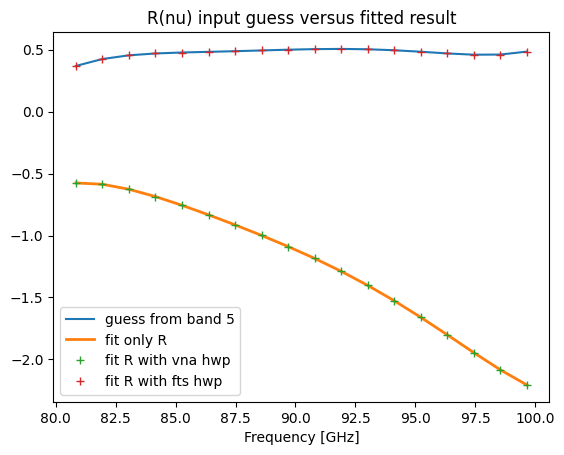

In [269]:
plt.figure()
plt.plot(f[mask], guessfunc(f[mask]), label='guess from band 5')
plt.plot(f[mask], fitfunc(f[mask]), label='fit only R', lw=2)
plt.plot(f[mask], Rfitfuncvna(f[mask]), '+',label='fit R with vna hwp', alpha=1)
plt.plot(f[mask], Rfitfuncfts(f[mask]),'+', label='fit R with fts hwp', alpha=1)
plt.legend()
plt.xlabel('Frequency [GHz]')
plt.title('R(nu) input guess versus fitted result')
plt.show()

I wonder if R's params should also be restricted to only be positive..

# Plot 2 - fit to  just R(nu0)

/global/homes/s/shreyasu/lart_testing_env/lib/python3.10/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/global/homes/s/shreyasu/lart_testing_env/lib/python3.10/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)


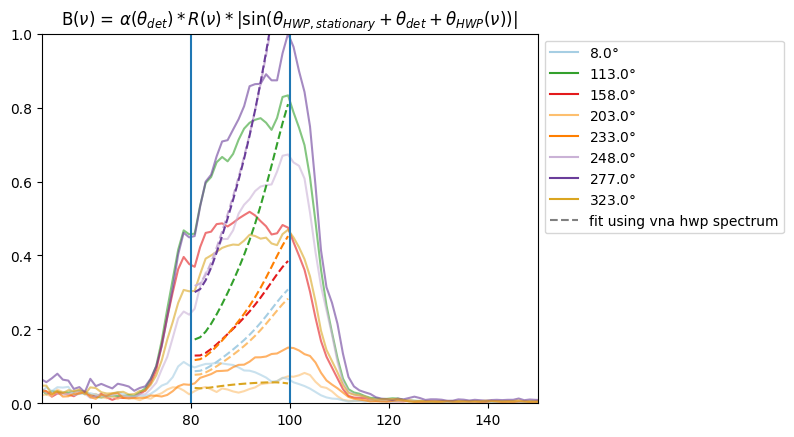

In [274]:
# ── plot ──────────────────────────────────────────────────────────────────────
plt.figure()
# fig, ax = plt.subplots(1, 2)

for i in range(n_groups):
    band = np.array(bands_groups1_bs_norm[i])
    freq = mv19_obs1['passband_results'][0]['frequency_ghz']
    mask_ = ~np.isnan(band)
    if mask_.any():
        plt.plot(freq[mask_], band[mask_], color=colors[i], alpha=0.6)

for i in range(n_groups):
    band = np.array(bands_groups4_bs_norm[i])
    freq = mv19_obs4['passband_results'][0]['frequency_ghz']
    mask_ = ~np.isnan(band)
    if mask_.any():
        plt.plot(freq[mask_], band[mask_], color=colors[i], alpha=0.6)
    
# fit1 when using vna hwp spectrum
for i, alpha_fit in fitted_alphas1_vna.items():
    y_fit = func3_vna(f[mask], gammas_avg[i], angle_stat_fit1_vna, Cguess, alpha_fit, Rpoly_fit2)
    plt.plot(f[mask], np.abs(y_fit), color=colors[i], ls='--')

# Label the pol angles
for i, (group_obs4, group_obs1, color) in enumerate(zip(groups_obs4, groups_obs1, colors)):
    if len(group_obs4) > 0:
        gamma_avg = np.degrees(np.mean(gamma4[group_obs4]))
        gammas_avg[i] = gamma_avg
    else:
        gamma_avg = np.degrees(np.mean(gamma1[group_obs1]))
        gammas_avg[i] = gamma_avg
    if math.isnan(gamma_avg):
        continue
    plt.plot([], [], color=color, label=rf'{np.round(gamma_avg)}$\degree$')

plt.plot([],[],color='grey', ls='--', label='fit using vna hwp spectrum')

plt.legend(bbox_to_anchor=(1,1))
plt.xlim(50, 150)
plt.ylim(0, 1)

# plt.axvspan(130, 160, alpha=0.5)
plt.axvline(hwp_bounds[0])
plt.axvline(hwp_bounds[1])
# ax[0].axhline(0.06, ls='--')
# ax[1].axhline(0.06, ls='--')
equationString = r'B($\nu$) = $\alpha (\theta_{det}) * R(\nu) * |$sin($\theta_{HWP, stationary} + \theta_{det} + \theta_{HWP}(\nu)$)|'

plt.title(equationString)
plt.show()

In [275]:
# Residuals
residuals2_onlyR = {}

for i, alpha_fit in fitted_alphas1_vna.items():
    y_fit = func3_vna(f[mask], gammas_avg[i], angle_stat_fit1_vna, Cguess, alpha_fit, Rpoly_fit2)
    # y_fit = np.abs(func3_vna(f[mask], gammas_avg[i], angle_stat_fit_posalpha, Cguess, alpha_fit, poly_fit_posalpha))
    y_fit_interp = np.interp(freq, f[mask], y_fit)

    residuals2_onlyR[i] = {}
    for obs, band_norm in [('obs1', bands_groups1_bs_norm[i]), ('obs4', bands_groups4_bs_norm[i])]:
        band = np.array(band_norm)
        if np.ndim(band) == 0:
            residuals2_onlyR[i][obs] = None
            continue
        mask_ = ~np.isnan(band)
        residuals2_onlyR[i][obs] = {
            'freq': freq[mask_],
            'resid': band[mask_] - y_fit_interp[mask_],
        }

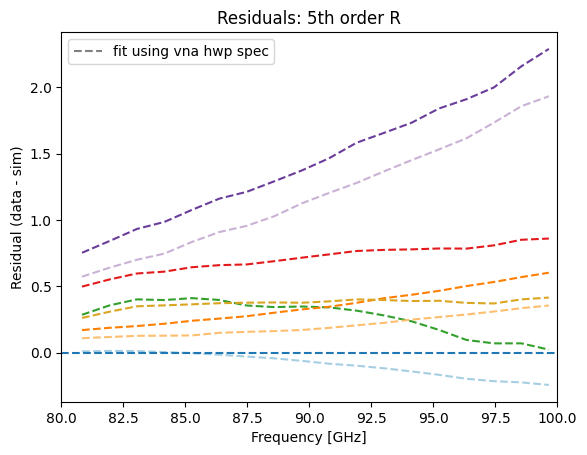

In [276]:
plt.figure()

# vna hwp residuals
for i, obs_residuals in residuals2_onlyR.items():
    for obs, val in obs_residuals.items():
        if val is not None:
            freq_mask = (val['freq'] >= hwp_bounds[0]) & (val['freq'] <= hwp_bounds[1])
            plt.plot(val['freq'][freq_mask], val['resid'][freq_mask], color=colors[i], ls='--')

plt.plot([],[], color='grey', ls='--', label='fit using vna hwp spec')

# plt.axvline(130, color='gray', lw=0.8)
plt.xlim(80, 100)
plt.axhline(0, ls='--')
plt.legend()
plt.xlabel('Frequency [GHz]')
plt.ylabel('Residual (data - sim)')
plt.title(f'Residuals: {order}th order R')
plt.show()

# FIT 3 - fit to just hwp spectrum
Fit to the HWP spectrum
- avg the quadratic fit params for the vna and fts hwp spectra
- use the fit R
- average the alphas from the fit params 
- average the stationary hwp angle

In [271]:
def hwp_phase_nu(x, poly_coeffs):
    """HWP phase-shift polynomial; degree = len(poly_coeffs) - 1 (2nd order)."""
    return np.polyval(poly_coeffs, x)


def func3_fit_hwp_ps(x, angle_pol, angle, const, alpha, R_poly_coeffs, hwp_poly_coeffs):

    # Phase shift is now the thing being fit — quadratic, via hwp_phase_nu
    angles_phase_shift = np.radians(hwp_phase_nu(x, hwp_poly_coeffs))
    angle_pol = np.radians(angle_pol)
    angle_rad = np.radians(angle)
    sine_arg = angle_pol + angles_phase_shift + angle_rad
    R = R_nu(x, R_poly_coeffs)
    return alpha * R * np.sin(sine_arg) + const


def error_func3_fit_hwp_ps(params, x_data_list, y_data_list, gammas, alphas, angle_stat, R_poly_coeffs):
    """
    params layout: [hwp_poly_coeff_0, hwp_poly_coeff_1, hwp_poly_coeff_2]  (2nd order)
    alphas, angle_stat, and R_poly_coeffs (band response, 6th order) are fixed givens.
    """
    hwp_poly_coeffs = params
    n_bands = len(BAND_INDICES)

    freqs = x_data_list[0]
    residuals = [
        y_data_list[i] - np.abs(func3_fit_hwp_ps(freqs, gammas[i], angle_stat, Cguess, alphas[i], R_poly_coeffs, hwp_poly_coeffs))
        for i in range(n_bands)
    ]
    return np.concatenate(residuals)

In [282]:
# initial guesses
x_avg = (result1_vna.x + result1_fts.x) / 2

# average of the two spectra: quad_coeffs_vna and quad_coeffs_fts
p0_hwp_avg = list((quad_coeffs_vna + quad_coeffs_fts) / 2)

fitted_alphas_arr_avg = x_avg[:n_bands]
fitted_alphas_avg  = dict(zip(BAND_INDICES, fitted_alphas_arr_avg))
angle_stat_fit_avg    = x_avg[n_bands]
# reusing the earliest R guess since it was at least positive
poly_p0  = list(coeffs_band[:POLY_DEG + 1])



In [273]:
def scalar_error_fit_hwp_ps(params, x_data_list, y_data_list, gammas, fitted_alphas_arr_avg, angle_stat_fit_avg, poly_p0):
    residuals = error_func3_fit_hwp_ps(params, x_data_list, y_data_list, gammas, fitted_alphas_arr_avg, angle_stat_fit_avg, poly_p0)
    return np.sum(residuals**2)

result_v3_fit_hwp_ps = basinhopping(
    scalar_error_fit_hwp_ps,
    p0_hwp_avg,
    minimizer_kwargs={
        "method": "L-BFGS-B",
        "args": (x_data_list, y_data_list, gammas, fitted_alphas_arr_avg, angle_stat_fit_avg, poly_p0),
    }
)

hwp_poly_fit = result_v3_fit_hwp_ps.x
hwp_poly_fit_func = np.poly1d(hwp_poly_fit)

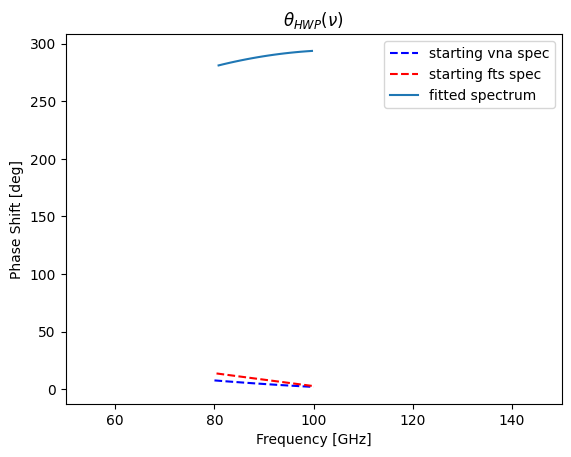

In [280]:
plt.figure()

## VNA
# plt.plot(f_hwp_vna, ps_hwp_vna, label='vna', alpha=0.5)
plt.plot(f_hwp_vna[mask_vna], func0_vna(f_hwp_vna[mask_vna]), color='b', ls='--', label='starting vna spec')

# ## FTS
# plt.plot(f_hwp_fts, ps_hwp_fts, label='fts', alpha=0.5)
plt.plot(f_hwp_fts[mask_fts], func0_fts(f_hwp_fts[mask_fts]), color='r', ls='--', label='starting fts spec')

# just fitted
plt.plot(f[mask], hwp_poly_fit_func(f[mask]), label='fitted spectrum')

plt.legend()
plt.xlabel('Frequency [GHz]')
plt.ylabel('Phase Shift [deg]')
plt.title(r'$\theta_{HWP}(\nu)$')
plt.xlim(50, 150)
plt.show()

# Plot 3 - fit to just hwp spectrum

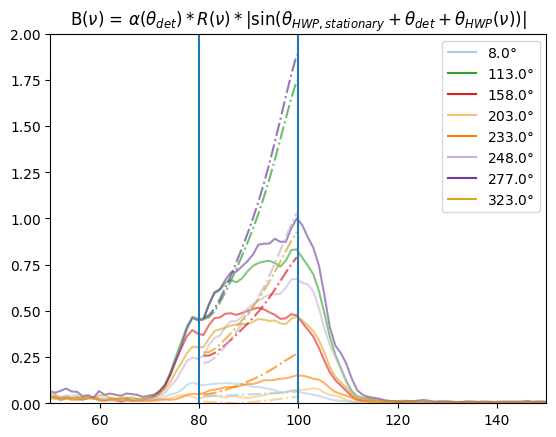

In [287]:
# ── plot ──────────────────────────────────────────────────────────────────────
plt.figure()
# fig, ax = plt.subplots(1, 2)

for i in range(n_groups):
    band = np.array(bands_groups1_bs_norm[i])
    freq = mv19_obs1['passband_results'][0]['frequency_ghz']
    mask_ = ~np.isnan(band)
    if mask_.any():
        plt.plot(freq[mask_], band[mask_], color=colors[i], alpha=0.6)

for i in range(n_groups):
    band = np.array(bands_groups4_bs_norm[i])
    freq = mv19_obs4['passband_results'][0]['frequency_ghz']
    mask_ = ~np.isnan(band)
    if mask_.any():
        plt.plot(freq[mask_], band[mask_], color=colors[i], alpha=0.6)
    
for i, alpha_fit in fitted_alphas_avg.items():
    y_fit = func3_fit_hwp_ps(f[mask], gammas_avg[i], angle_stat_fit_avg, Cguess, alpha_fit, poly_fit_fitR, hwp_poly_fit)
    plt.plot(f[mask], np.abs(y_fit), color=colors[i], ls='-.', alpha=0.7)

# Label the pol angles
for i, (group_obs4, group_obs1, color) in enumerate(zip(groups_obs4, groups_obs1, colors)):
    if len(group_obs4) > 0:
        gamma_avg = np.degrees(np.mean(gamma4[group_obs4]))
        gammas_avg[i] = gamma_avg
    else:
        gamma_avg = np.degrees(np.mean(gamma1[group_obs1]))
        gammas_avg[i] = gamma_avg
    if math.isnan(gamma_avg):
        continue
    plt.plot([], [], color=color, label=rf'{np.round(gamma_avg)}$\degree$')

plt.legend()
plt.xlim(50, 150)
plt.ylim(0, 2)
plt.axvline(hwp_bounds[0])
plt.axvline(hwp_bounds[1])

# plt.axvspan(130, 160, alpha=0.5)
# ax[0].axhline(0.06, ls='--')
# ax[1].axhline(0.06, ls='--')
equationString = r'B($\nu$) = $\alpha (\theta_{det}) * R(\nu) * |$sin($\theta_{HWP, stationary} + \theta_{det} + \theta_{HWP}(\nu)$)|'

plt.title(equationString)
plt.show()

In [288]:
residuals_fitting_hwp_ps = {}
# freq = mv19_obs1['passband_results'][0]['frequency_ghz']

for i, alpha_fit in fitted_alphas_avg.items():
    y_fit = np.abs(func3_fit_hwp_ps(f[mask], gammas_avg[i], angle_stat_fit_avg, Cguess, alpha_fit, poly_fit_fitR, hwp_poly_fit))
    y_fit_interp = np.interp(freq, f[mask], y_fit)

    residuals_fitting_hwp_ps[i] = {}
    for obs, band_norm in [('obs1', bands_groups1_bs_norm[i]), ('obs4', bands_groups4_bs_norm[i])]:
        band = np.array(band_norm)
        if np.ndim(band) == 0:
            residuals_fitting_hwp_ps[i][obs] = None
            continue
        mask_ = ~np.isnan(band)
        residuals_fitting_hwp_ps[i][obs] = {
            'freq': freq[mask_],
            'resid': band[mask_] - y_fit_interp[mask_],
        }

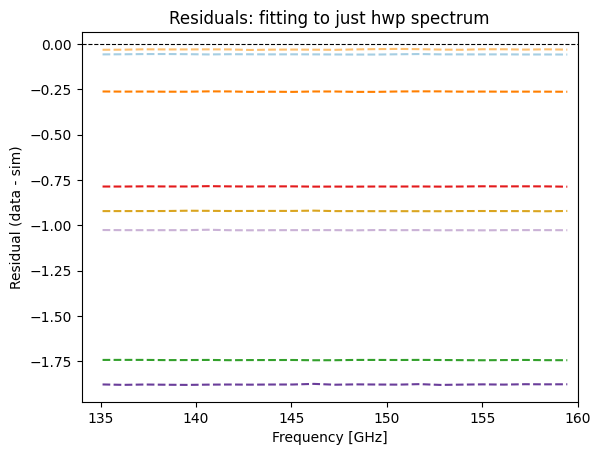

In [289]:
plt.figure()

# vna hwp residuals and fitting to only R
for i, obs_residuals in residuals_fitting_hwp_ps.items():
    for obs, val in obs_residuals.items():
        if val is not None:
            freq_mask = (val['freq'] >= 135) & (val['freq'] <= 160)
            plt.plot(val['freq'][freq_mask], val['resid'][freq_mask], color=colors[i], ls='--')

plt.axhline(0, color='k', lw=0.8, ls='--')
# plt.axvline(130, color='gray', lw=0.8)
plt.axvline(160, color='gray', lw=0.8)
plt.xlim(134, 160)
plt.xlabel('Frequency [GHz]')
plt.ylabel('Residual (data - sim)')
plt.title(f'Residuals: fitting to just hwp spectrum')
plt.show()